In [1]:
import sys
import time


import numpy as np
import openml
import pandas as pd
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, get_scorer, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder

class GRANDEClassifier(ClassifierMixin, BaseEstimator):
    """Sklearn-compatible wrapper for standalone GRANDE (trained from scratch per dataset)."""

    def __init__(self, depth=5, n_estimators=1024, learning_rate_weights=0.001,
                 learning_rate_index=0.01, learning_rate_values=0.05,
                 learning_rate_leaf=0.05, dropout=0.2, selected_variables=0.8,
                 data_subset_fraction=1.0, epochs=250, batch_size=256,
                 early_stopping_epochs=50, random_seed=42, verbose=0):
        self.depth = depth
        self.n_estimators = n_estimators
        self.learning_rate_weights = learning_rate_weights
        self.learning_rate_index = learning_rate_index
        self.learning_rate_values = learning_rate_values
        self.learning_rate_leaf = learning_rate_leaf
        self.dropout = dropout
        self.selected_variables = selected_variables
        self.data_subset_fraction = data_subset_fraction
        self.epochs = epochs
        self.batch_size = batch_size
        self.early_stopping_epochs = early_stopping_epochs
        self.random_seed = random_seed
        self.verbose = verbose

    def fit(self, X, y):
        from grande import GRANDE

        self.le_ = LabelEncoder()
        y_encoded = pd.Series(self.le_.fit_transform(y))
        self.classes_ = self.le_.classes_

        n_classes = len(self.classes_)
        problem_type = 'binary' if n_classes == 2 else 'multiclass'

        params = {
            'depth': self.depth,
            'n_estimators': self.n_estimators,
            'learning_rate_weights': self.learning_rate_weights,
            'learning_rate_index': self.learning_rate_index,
            'learning_rate_values': self.learning_rate_values,
            'learning_rate_leaf': self.learning_rate_leaf,
            'learning_rate_embedding': 0.02,
            'use_category_embeddings': False,
            'embedding_dim_cat': 8,
            'use_numeric_embeddings': False,
            'embedding_dim_num': 8,
            'embedding_threshold': 1,
            'loo_cardinality': 10,
            'dropout': self.dropout,
            'selected_variables': self.selected_variables,
            'data_subset_fraction': self.data_subset_fraction,
            'bootstrap': False,
            'missing_values': False,
            'optimizer': 'adam',
            'cosine_decay_restarts': False,
            'reduce_on_plateau_scheduler': True,
            'label_smoothing': 0.0,
            'use_class_weights': False,
            'focal_loss': False,
            'swa': False,
            'es_metric': True,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'early_stopping_epochs': self.early_stopping_epochs,
            'use_freq_enc': False,
            'use_robust_scale_smoothing': False,
            'problem_type': problem_type,
            'random_seed': self.random_seed,
            'verbose': self.verbose,
        }

        X_train, X_val, y_train, y_val = train_test_split(
            pd.DataFrame(X), y_encoded, test_size=0.2,
            random_state=self.random_seed, stratify=y_encoded,
        )

        self.model_ = GRANDE(params=params)
        self.model_.fit(X=X_train, y=y_train, X_val=X_val, y_val=y_val)
        return self

    def predict(self, X):
        preds = self.model_.predict(pd.DataFrame(X))
        return self.le_.inverse_transform(preds.astype(int))

    def predict_proba(self, X):
        return self.model_.predict_proba(pd.DataFrame(X))

In [3]:

# Import your custom model
sys.path.append('../')  # Adjust path to import ticl
from ticl.prediction.mothernet import MotherNetClassifier

# Configuration
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 2
RANDOM_SEEDS = [42]  # Reduced seeds to save time for testing
PERFORM_HPO = False
SUITE_ID = 99  # OpenML-CC18
MAX_SAMPLES = 2000  # Lower limit for faster testing, increase to 10000 for full run
DIAGNOSTIC_DATASET_LIMIT = 3

# Define Models and Hyperparameter Spaces
models_config = {
    'Majority (Prior)': {
        'model': DummyClassifier(strategy='prior'),
        'params': {}
    },
    'Random (Uniform)': {
        'model': DummyClassifier(strategy='uniform', random_state=0),
        'params': {}
    },
    'CART (Baseline)': {
        'model': DecisionTreeClassifier(),
        'params': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'GRANDE (standalone)': {
        'model': GRANDEClassifier(depth=4, n_estimators=64, epochs=250, verbose=0),
        'params': {},
        'skip_pipeline': True,  # GRANDE handles its own preprocessing
    },
    'MLP Mothernet': {
        'model': MotherNetClassifier(
            device='cuda',
            path="/work/mherre/ticl/models_diff/mn_n2048_03_19_2026_08_46_29_epoch_630.cpkt",
            # path = "/work/mherre/ticl/models_diff/__mn_03_13_2026_13_54_28_epoch_20.cpkt",
        ),
        'params': {}
    },
    'GRANDE Mothernet (depthwise)': {
        'model': MotherNetClassifier(
            device='cuda',
            path="/work/mherre/ticl/models_diff/__mn_childmodelgrande_grandedecodervariantdepthwise_factorized_stats_grandesplittemperatureannealsteps10000_grandesplittemperatureend0.5_nestimators64_n2048_treedepth4_03_18_2026_14_43_42_epoch_190.cpkt",
        ),
        'params': {}
    },
    'GRANDE Mothernet (factorized) V1': {
        'model': MotherNetClassifier(
            device='cuda',
            path="/work/mherre/ticl/models_diff/mn_b16_childmodelgrande_datasubsetfraction0.5534_d512_H1024_e1024_E50_grandedecodervariantfactorized_stats_grandediversitylossweight0.01_grandedropout0.05_l0.0001479_nestimators128_N6_n2048_selectedvariables32_w0.01_03_28_2026_04_47_29_epoch_on_exit.cpkt",
        ),
        'params': {}
    },
    'GRANDE Mothernet (factorized) V2': {
        'model': MotherNetClassifier(
            device='cuda',
            path="/work/mherre/ticl/models_diff/mn_b16_childmodelgrande_datasubsetfraction0.5382_d512_H4096_e256_E50_grandedecodervariantfactorized_stats_grandediversitylossweight0.005_grandedropout0.3_l5.27e-05_nestimators64_n2048_treedepth4_03_28_2026_12_58_53_epoch_on_exit.cpkt",
        ),
        'params': {}
    },
    'GRANDE Mothernet (factorized) V3': {
        'model': MotherNetClassifier(
            device='cuda',
            path="/work/mherre/ticl/models_diff/mn_b16_childmodelgrande_datasubsetfraction0.6095_H4096_e1024_E50_grandedecodervariantfactorized_stats_grandediversitylossweight0.01_grandedropout0.05_l1.37e-05_nestimators128_n2048_selectedvariables32_03_28_2026_15_36_24_epoch_on_exit.cpkt",
        ),
        'params': {}
    },
    'GRANDE Mothernet (factorized) V4': {
        'model': MotherNetClassifier(

            device='cuda',
            path="/work/mherre/ticl//models_diff/mn_childmodelgrande_datasubsetfraction0.8551_e1024_E50_grandedecodervariantfactorized_stats_grandediversitylossweight0.005_l5e-05_nestimators128_n2048_selectedvariables32_treedepth6_w0.1_03_28_2026_10_53_56_epoch_on_exit.cpkt",
        ),
        'params': {}
    },
}

model_order = list(models_config.keys())

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc_ovr'  # Use OVR to support multiclass safely
}

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [4]:
# --- HELPER: Universal Preprocessor ---
def get_clean_pipeline(model, X):
    """
    Wraps model in a pipeline to handle NaNs and categoricals automatically.
    This prevents data leakage by fitting transformers only on train folds.
    """
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    num_cols = X.select_dtypes(include=['number']).columns

    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_cols),
            ('cat', cat_transformer, cat_cols)
        ]
    )

    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])


In [5]:
# --- CORE BENCHMARK ENGINE ---
def run_nested_benchmark_on_suite(models_config, seeds, outer_folds, inner_folds, scoring, perform_hpo=True):
    all_results = []
    all_predictions = []
    scorers = {metric: get_scorer(spec) for metric, spec in scoring.items()}

    # 1. Fetch and Filter Dataset List
    print(f"Fetching Suite ID {SUITE_ID}...")
    suite = openml.study.get_suite(SUITE_ID)
    dset_meta = openml.datasets.list_datasets(output_format="dataframe")

    # Filter tasks
    tasks_to_run = []
    for task_id in suite.tasks:
        try:
            task_meta = openml.tasks.get_task(task_id, download_data=False)
            did = task_meta.dataset_id
            if did in dset_meta.index and dset_meta.loc[did, 'NumberOfInstances'] < MAX_SAMPLES:
                tasks_to_run.append((task_id, dset_meta.loc[did, 'name']))
        except Exception:
            pass

    print(f"Selected {len(tasks_to_run)} datasets (< {MAX_SAMPLES} samples).")

    # 2. Loop through Datasets
    for task_id, dset_name in tasks_to_run:
        print(f"\n=== Dataset: {dset_name} (Task {task_id}) ===")

        try:
            task = openml.tasks.get_task(task_id)
            X, y = task.get_X_and_y(dataset_format='dataframe')
            X = X.reset_index(drop=True)
            y = pd.Series(y).reset_index(drop=True)

            for seed in seeds:
                outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

                for name, config in models_config.items():
                    print(f"  -> {name} (seed={seed})")
                    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
                        X_train = X.iloc[train_idx].copy()
                        X_test = X.iloc[test_idx].copy()
                        y_train = y.iloc[train_idx].copy()
                        y_test = y.iloc[test_idx].copy()

                        base_model = clone(config['model'])

                        if config.get('skip_pipeline', False):
                            clf = base_model
                        else:
                            pipeline_model = get_clean_pipeline(base_model, X_train)

                            if perform_hpo and config['params']:
                                param_grid = {
                                    f'classifier__{param_name}': values
                                    for param_name, values in config['params'].items()
                                }
                                clf = GridSearchCV(
                                    estimator=pipeline_model,
                                    param_grid=param_grid,
                                    cv=inner_folds,
                                    scoring='roc_auc_ovr',
                                    n_jobs=1,
                                )
                            else:
                                clf = pipeline_model

                        try:
                            fit_start = time.perf_counter()
                            clf.fit(X_train, y_train)
                            fit_time = time.perf_counter() - fit_start

                            score_start = time.perf_counter()
                            y_pred = clf.predict(X_test)
                            y_proba = clf.predict_proba(X_test) if hasattr(clf, "predict_proba") else None
                            inference_time = time.perf_counter() - score_start

                            res = {
                                'Dataset': dset_name,
                                'Model': name,
                                'Seed': seed,
                                'Fold': fold_idx,
                                'Fit Time (s)': fit_time,
                                'Inference Time (s)': inference_time,
                            }
                            for metric, scorer in scorers.items():
                                res[metric] = scorer(clf, X_test, y_test)
                            all_results.append(res)

                            if y_proba is not None:
                                confidence = y_proba.max(axis=1)
                            else:
                                confidence = np.full(len(y_test), np.nan)

                            for sample_idx, (true_value, pred_value, conf_value) in enumerate(
                                zip(y_test.tolist(), y_pred.tolist(), confidence.tolist())
                            ):
                                all_predictions.append({
                                    'Dataset': dset_name,
                                    'Model': name,
                                    'Seed': seed,
                                    'Fold': fold_idx,
                                    'Sample Index': int(test_idx[sample_idx]),
                                    'y_true': str(true_value),
                                    'y_pred': str(pred_value),
                                    'confidence': conf_value,
                                    'correct': bool(true_value == pred_value),
                                })
                        except Exception as exc:
                            print(f"Failed on {name}, fold {fold_idx}: {exc}")
        except Exception as exc:
            print(f"!! Critical Error on Dataset {dset_name}: {exc}")

    return pd.DataFrame(all_results), pd.DataFrame(all_predictions)


# Run Benchmark
df_results, df_predictions = run_nested_benchmark_on_suite(
    models_config,
    RANDOM_SEEDS,
    N_OUTER_FOLDS,
    N_INNER_FOLDS,
    scoring,
    perform_hpo=PERFORM_HPO,
)

Fetching Suite ID 99...


/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


Selected 29 datasets (< 2000 samples).

=== Dataset: balance-scale (Task 11) ===
  -> Majority (Prior) (seed=42)
  -> Random (Uniform) (seed=42)
  -> CART (Baseline) (seed=42)
  -> GRANDE (standalone) (seed=42)
Restoring best model from epoch with val score: 0.19411903381347656
Restoring best model from epoch with val score: 0.18202377319335938
Restoring best model from epoch with val score: 0.18407548904418947
Restoring best model from epoch with val score: 0.2393910789489746
Restoring best model from epoch with val score: 0.23567916870117187
  -> MLP Mothernet (seed=42)
Number of parameters in backbone:  25233408
  -> GRANDE Mothernet (depthwise) (seed=42)
Number of parameters in backbone:  25233408
  -> GRANDE Mothernet (factorized) V1 (seed=42)
Number of parameters in backbone:  50399232
  -> GRANDE Mothernet (factorized) V2 (seed=42)
Number of parameters in backbone:  6325248
  -> GRANDE Mothernet (factorized) V3 (seed=42)
Number of parameters in backbone:  100798464
  -> GRANDE M

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


  -> GRANDE (standalone) (seed=42)
Restoring best model from epoch with val score: -0.9894625922023182
Restoring best model from epoch with val score: -0.9926238145416227
Restoring best model from epoch with val score: -0.9877063575693713
Restoring best model from epoch with val score: -0.9953769559032717
Restoring best model from epoch with val score: -0.9922725676150334
  -> MLP Mothernet (seed=42)
  -> GRANDE Mothernet (depthwise) (seed=42)
  -> GRANDE Mothernet (factorized) V1 (seed=42)
  -> GRANDE Mothernet (factorized) V2 (seed=42)
  -> GRANDE Mothernet (factorized) V3 (seed=42)
  -> GRANDE Mothernet (factorized) V4 (seed=42)

=== Dataset: cmc (Task 23) ===
  -> Majority (Prior) (seed=42)
  -> Random (Uniform) (seed=42)


...

  -> CART (Baseline) (seed=42)
  -> GRANDE (standalone) (seed=42)
Restoring best model from epoch with val score: 0.5767096982508227
Restoring best model from epoch with val score: 0.5789951680174211
Restoring best model from epoch with val score: 0.6201934446475896
Restoring best model from epoch with val score: 0.6088440211256217
Restoring best model from epoch with val score: 0.6020596862989224
  -> MLP Mothernet (seed=42)
  -> GRANDE Mothernet (depthwise) (seed=42)
  -> GRANDE Mothernet (factorized) V1 (seed=42)
  -> GRANDE Mothernet (factorized) V2 (seed=42)
  -> GRANDE Mothernet (factorized) V3 (seed=42)
  -> GRANDE Mothernet (factorized) V4 (seed=42)

=== Dataset: climate-model-simulation-crashes (Task 146819) ===
  -> Majority (Prior) (seed=42)
  -> Random (Uniform) (seed=42)
  -> CART (Baseline) (seed=42)


/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


  -> GRANDE (standalone) (seed=42)
Restoring best model from epoch with val score: -0.9874999999999999
Restoring best model from epoch with val score: -0.8875000000000001
Restoring best model from epoch with val score: -0.9892857142857142
Restoring best model from epoch with val score: -0.9696428571428571
Restoring best model from epoch with val score: -0.9839285714285715
  -> MLP Mothernet (seed=42)
  -> GRANDE Mothernet (depthwise) (seed=42)
  -> GRANDE Mothernet (factorized) V1 (seed=42)
  -> GRANDE Mothernet (factorized) V2 (seed=42)
  -> GRANDE Mothernet (factorized) V3 (seed=42)
  -> GRANDE Mothernet (factorized) V4 (seed=42)

=== Dataset: car (Task 146821) ===
  -> Majority (Prior) (seed=42)
  -> Random (Uniform) (seed=42)


/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/tasks/functions.py:372: FutureWarning: Starting from Version 0.15.0 `download_splits` will default to ``False`` instead of ``True`` and be independent from `download_data`. To disable this message until version 0.15 explicitly set `download_splits` to a bool.
  warnings.warn(
/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/openml/datasets/functions.py:437: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


  -> CART (Baseline) (seed=42)
  -> GRANDE (standalone) (seed=42)
Restoring best model from epoch with val score: 0.03621799119543082
Restoring best model from epoch with val score: 0.04906258987605787
Restoring best model from epoch with val score: 0.039382498186848226
Restoring best model from epoch with val score: 0.03884472076643245
Restoring best model from epoch with val score: 0.09299432435190634
  -> MLP Mothernet (seed=42)
  -> GRANDE Mothernet (depthwise) (seed=42)
  -> GRANDE Mothernet (factorized) V1 (seed=42)
  -> GRANDE Mothernet (factorized) V2 (seed=42)
  -> GRANDE Mothernet (factorized) V3 (seed=42)
  -> GRANDE Mothernet (factorized) V4 (seed=42)


In [6]:
def generate_scientific_table(df, baseline_name, my_model_name, metrics):
    if df.empty:
        return pd.DataFrame()

    summary = []
    for metric in metrics:
        base_scores = df[df['Model'] == baseline_name][metric]
        my_scores = df[df['Model'] == my_model_name][metric]

        base_mean, base_std = base_scores.mean(), base_scores.std()
        my_mean, my_std = my_scores.mean(), my_scores.std()

        try:
            _, p_value = stats.wilcoxon(base_scores, my_scores)
        except Exception:
            p_value = 1.0

        delta = my_mean - base_mean
        significance = "*" if p_value < 0.05 else "ns"
        if p_value < 0.01:
            significance = "**"
        if p_value < 0.001:
            significance = "***"

        summary.append({
            'Metric': metric,
            f'{baseline_name} (Mean ± Std)': f"{base_mean:.4f} ± {base_std:.4f}",
            f'{my_model_name} (Mean ± Std)': f"{my_mean:.4f} ± {my_std:.4f}",
            'Delta': f"{delta:+.4f}",
            'p-value': f"{p_value:.2e} ({significance})",
        })

    return pd.DataFrame(summary)


def summarize_models(df, metrics):
    rows = []
    for model_name, model_df in df.groupby('Model'):
        row = {'Model': model_name}
        for metric in metrics:
            row[metric] = f"{model_df[metric].mean():.4f} ± {model_df[metric].std():.4f}"
        rows.append(row)

    summary = pd.DataFrame(rows)
    summary['Model'] = pd.Categorical(summary['Model'], categories=model_order, ordered=True)
    return summary.sort_values('Model')


metrics_to_report = ['roc_auc', 'f1', 'accuracy', 'Inference Time (s)']

if not df_results.empty:
    print("--- Overall Summary ---")
    print(summarize_models(df_results, metrics_to_report).to_markdown(index=False))

    print("\n--- Comparison: CART vs GRANDE ---")
    final_table_grande = generate_scientific_table(
        df_results,
        'CART (Baseline)',
        'GRANDE Mothernet',
        metrics_to_report,
    )
    print(final_table_grande.to_markdown(index=False))

    print("\n--- Comparison: CART vs MLP ---")
    final_table_mlp = generate_scientific_table(
        df_results,
        'CART (Baseline)',
        'MLP Mothernet',
        metrics_to_report,
    )
    print(final_table_mlp.to_markdown(index=False))


--- Overall Summary ---
| Model                            | roc_auc         | f1              | accuracy        | Inference Time (s)   |
|:---------------------------------|:----------------|:----------------|:----------------|:---------------------|
| Majority (Prior)                 | 0.5000 ± 0.0000 | 0.2820 ± 0.1662 | 0.5380 ± 0.2555 | 0.0044 ± 0.0021      |
| Random (Uniform)                 | 0.5000 ± 0.0000 | 0.3494 ± 0.1593 | 0.3745 ± 0.1666 | 0.0047 ± 0.0021      |
| CART (Baseline)                  | 0.7622 ± 0.1461 | 0.7139 ± 0.1764 | 0.7695 ± 0.1738 | 0.0046 ± 0.0021      |
| GRANDE (standalone)              | 0.8876 ± 0.1236 | 0.7387 ± 0.2042 | 0.8233 ± 0.1699 | 0.3204 ± 0.6466      |
| MLP Mothernet                    | 0.8804 ± 0.1123 | 0.6969 ± 0.2232 | 0.8005 ± 0.1861 | 0.0078 ± 0.0022      |
| GRANDE Mothernet (depthwise)     | 0.7912 ± 0.1320 | 0.5600 ± 0.2252 | 0.7217 ± 0.2036 | 0.0206 ± 0.0251      |
| GRANDE Mothernet (factorized) V1 | 0.8306 ± 0.1165 | 0.5961 ± 

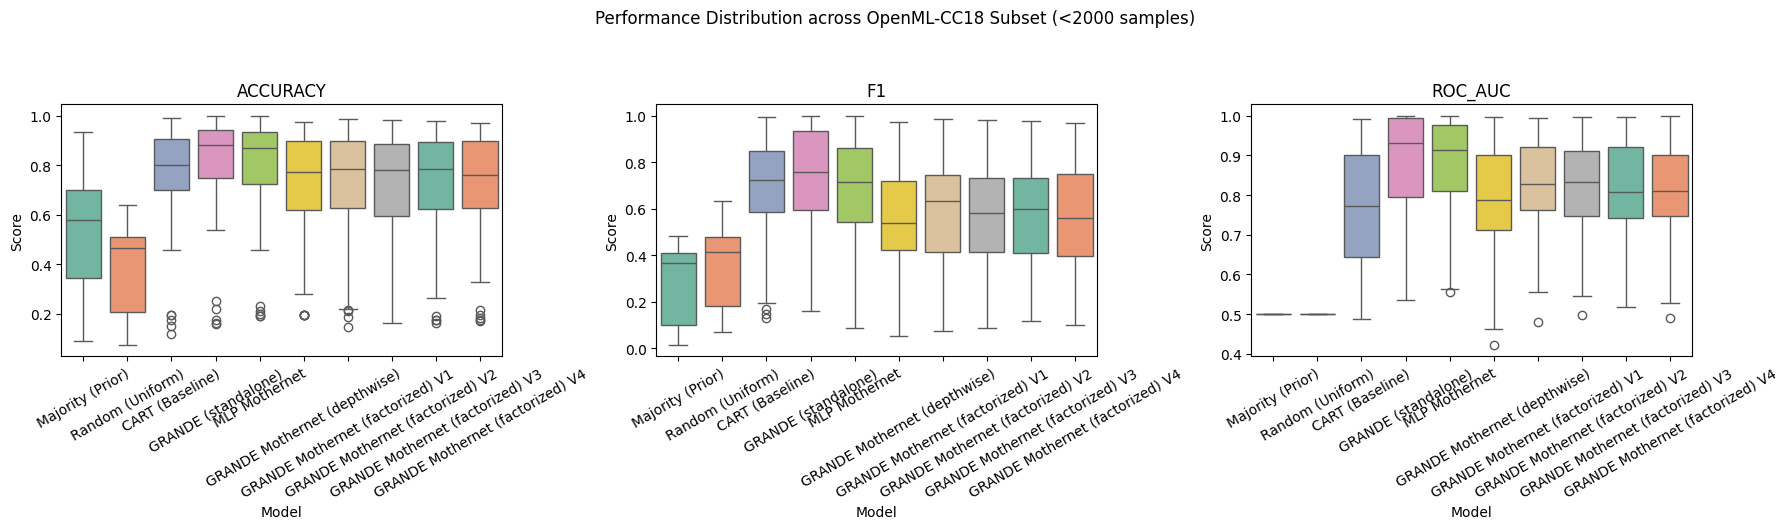


Mean ROC AUC per Dataset:
| Dataset                          |   Majority (Prior) |   Random (Uniform) |   CART (Baseline) |   GRANDE (standalone) |   MLP Mothernet |   GRANDE Mothernet (depthwise) |   GRANDE Mothernet (factorized) V1 |   GRANDE Mothernet (factorized) V2 |   GRANDE Mothernet (factorized) V3 |   GRANDE Mothernet (factorized) V4 |
|:---------------------------------|-------------------:|-------------------:|------------------:|----------------------:|----------------:|-------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|
| MiceProtein                      |                0.5 |                0.5 |             0.907 |                 1     |           0.945 |                          0.879 |                              0.862 |                              0.85  |                              0.791 |                              0.838 |
| analc

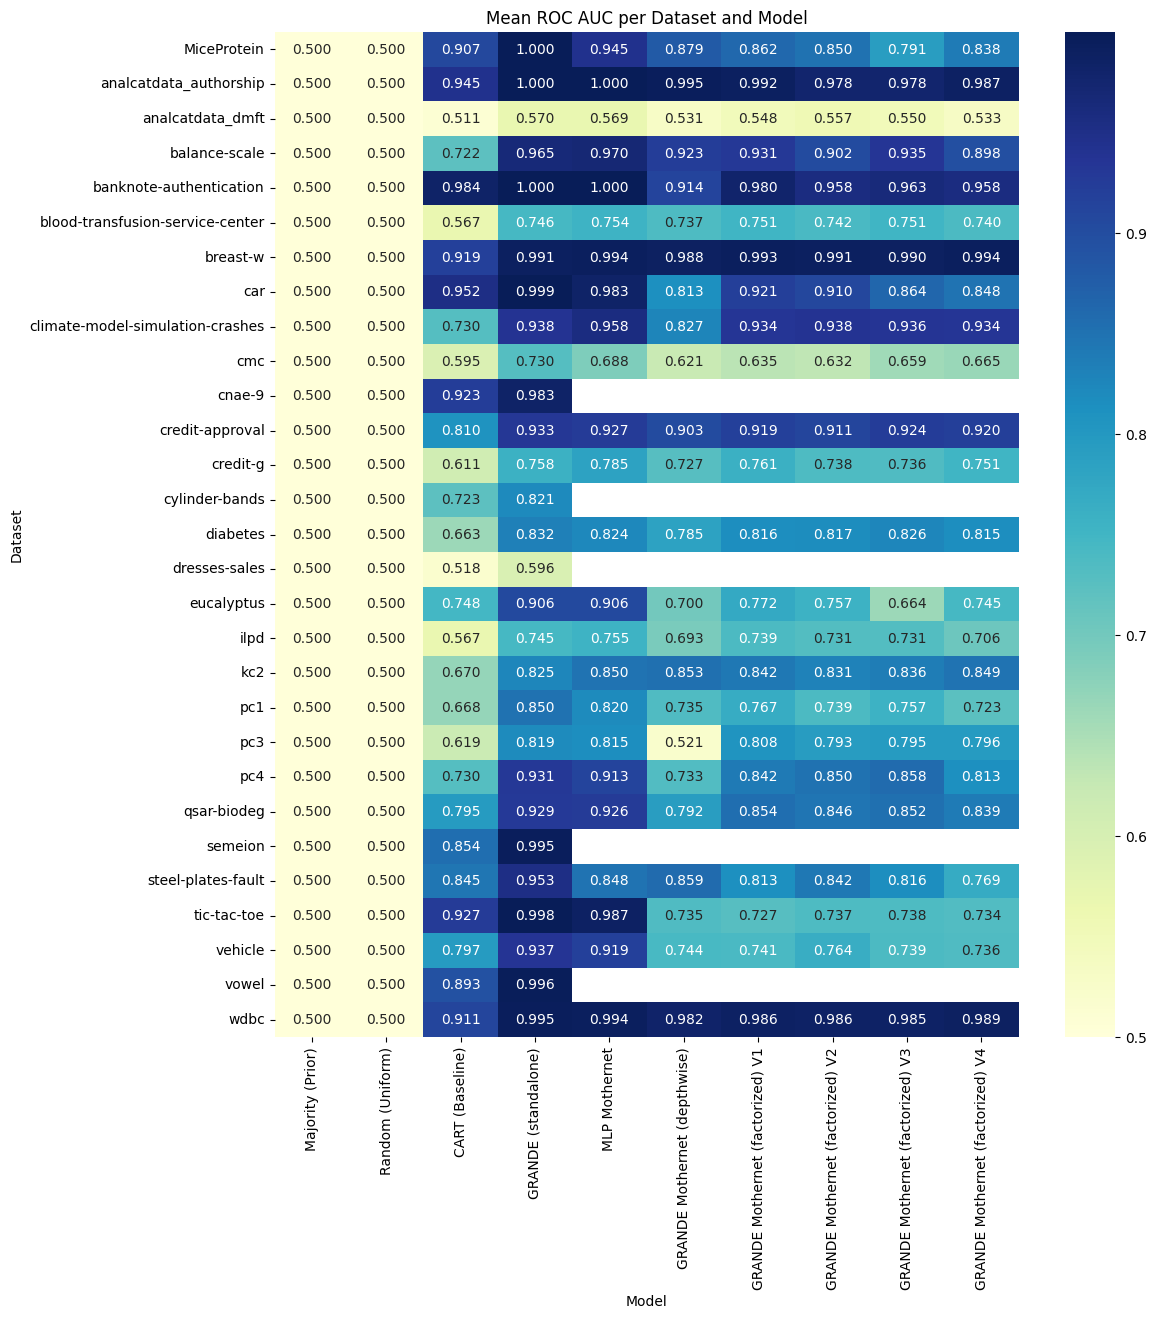

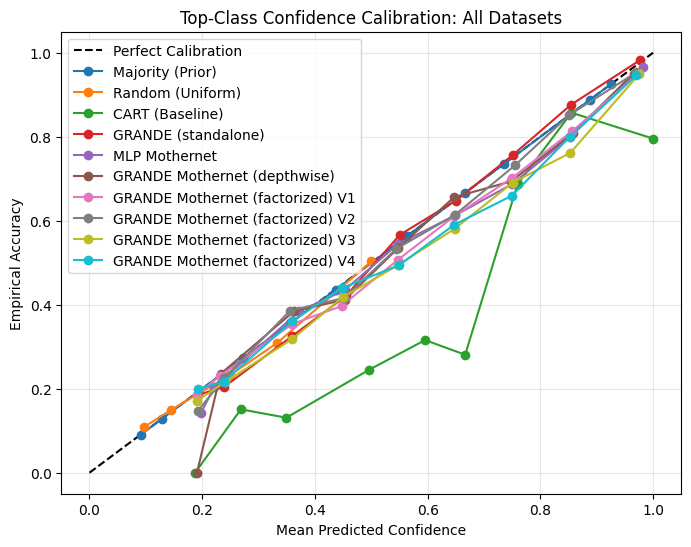


Diagnostic datasets (worst GRANDE vs CART macro-F1 gaps):
['MiceProtein', 'analcatdata_authorship', 'analcatdata_dmft']

=== Diagnostics: MiceProtein ===


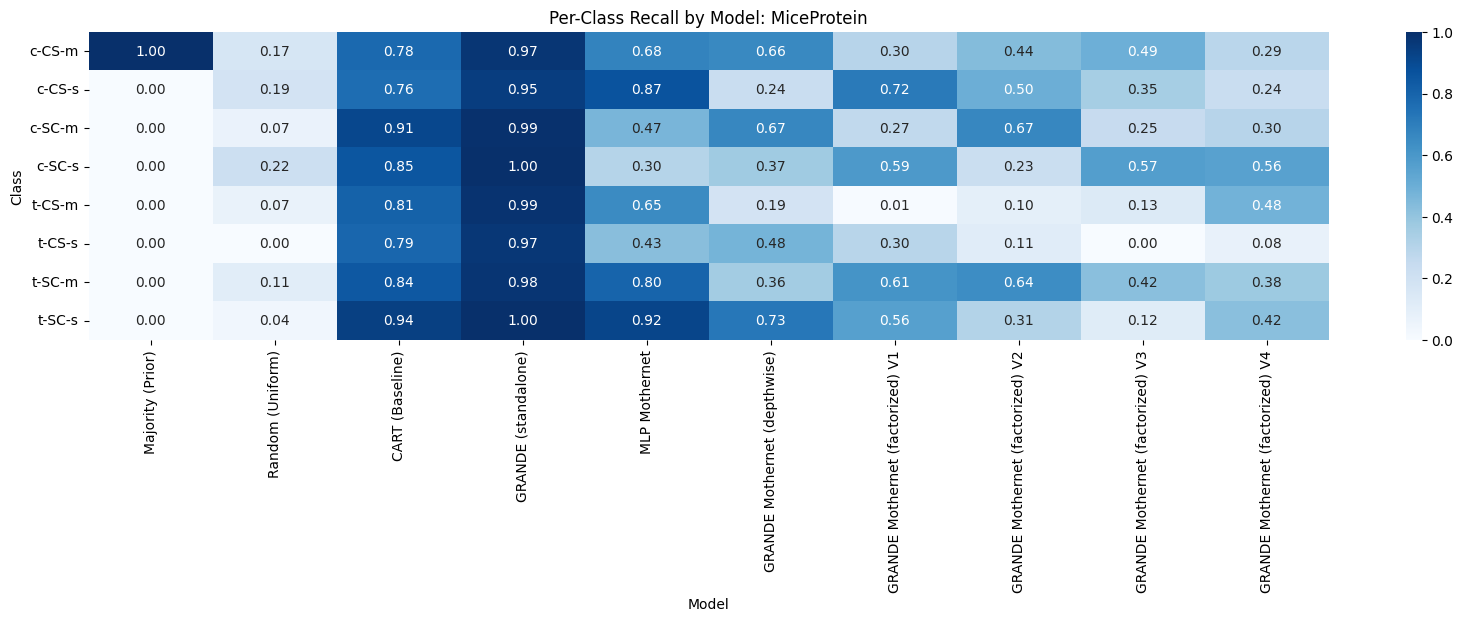

| Class   |   Majority (Prior) |   Random (Uniform) |   CART (Baseline) |   GRANDE (standalone) |   MLP Mothernet |   GRANDE Mothernet (depthwise) |   GRANDE Mothernet (factorized) V1 |   GRANDE Mothernet (factorized) V2 |   GRANDE Mothernet (factorized) V3 |   GRANDE Mothernet (factorized) V4 |
|:--------|-------------------:|-------------------:|------------------:|----------------------:|----------------:|-------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|
| c-CS-m  |                  1 |              0.167 |             0.78  |                 0.973 |           0.68  |                          0.66  |                              0.3   |                              0.44  |                              0.493 |                              0.287 |
| c-CS-s  |                  0 |              0.185 |             0.763 |                 0.948 |           0

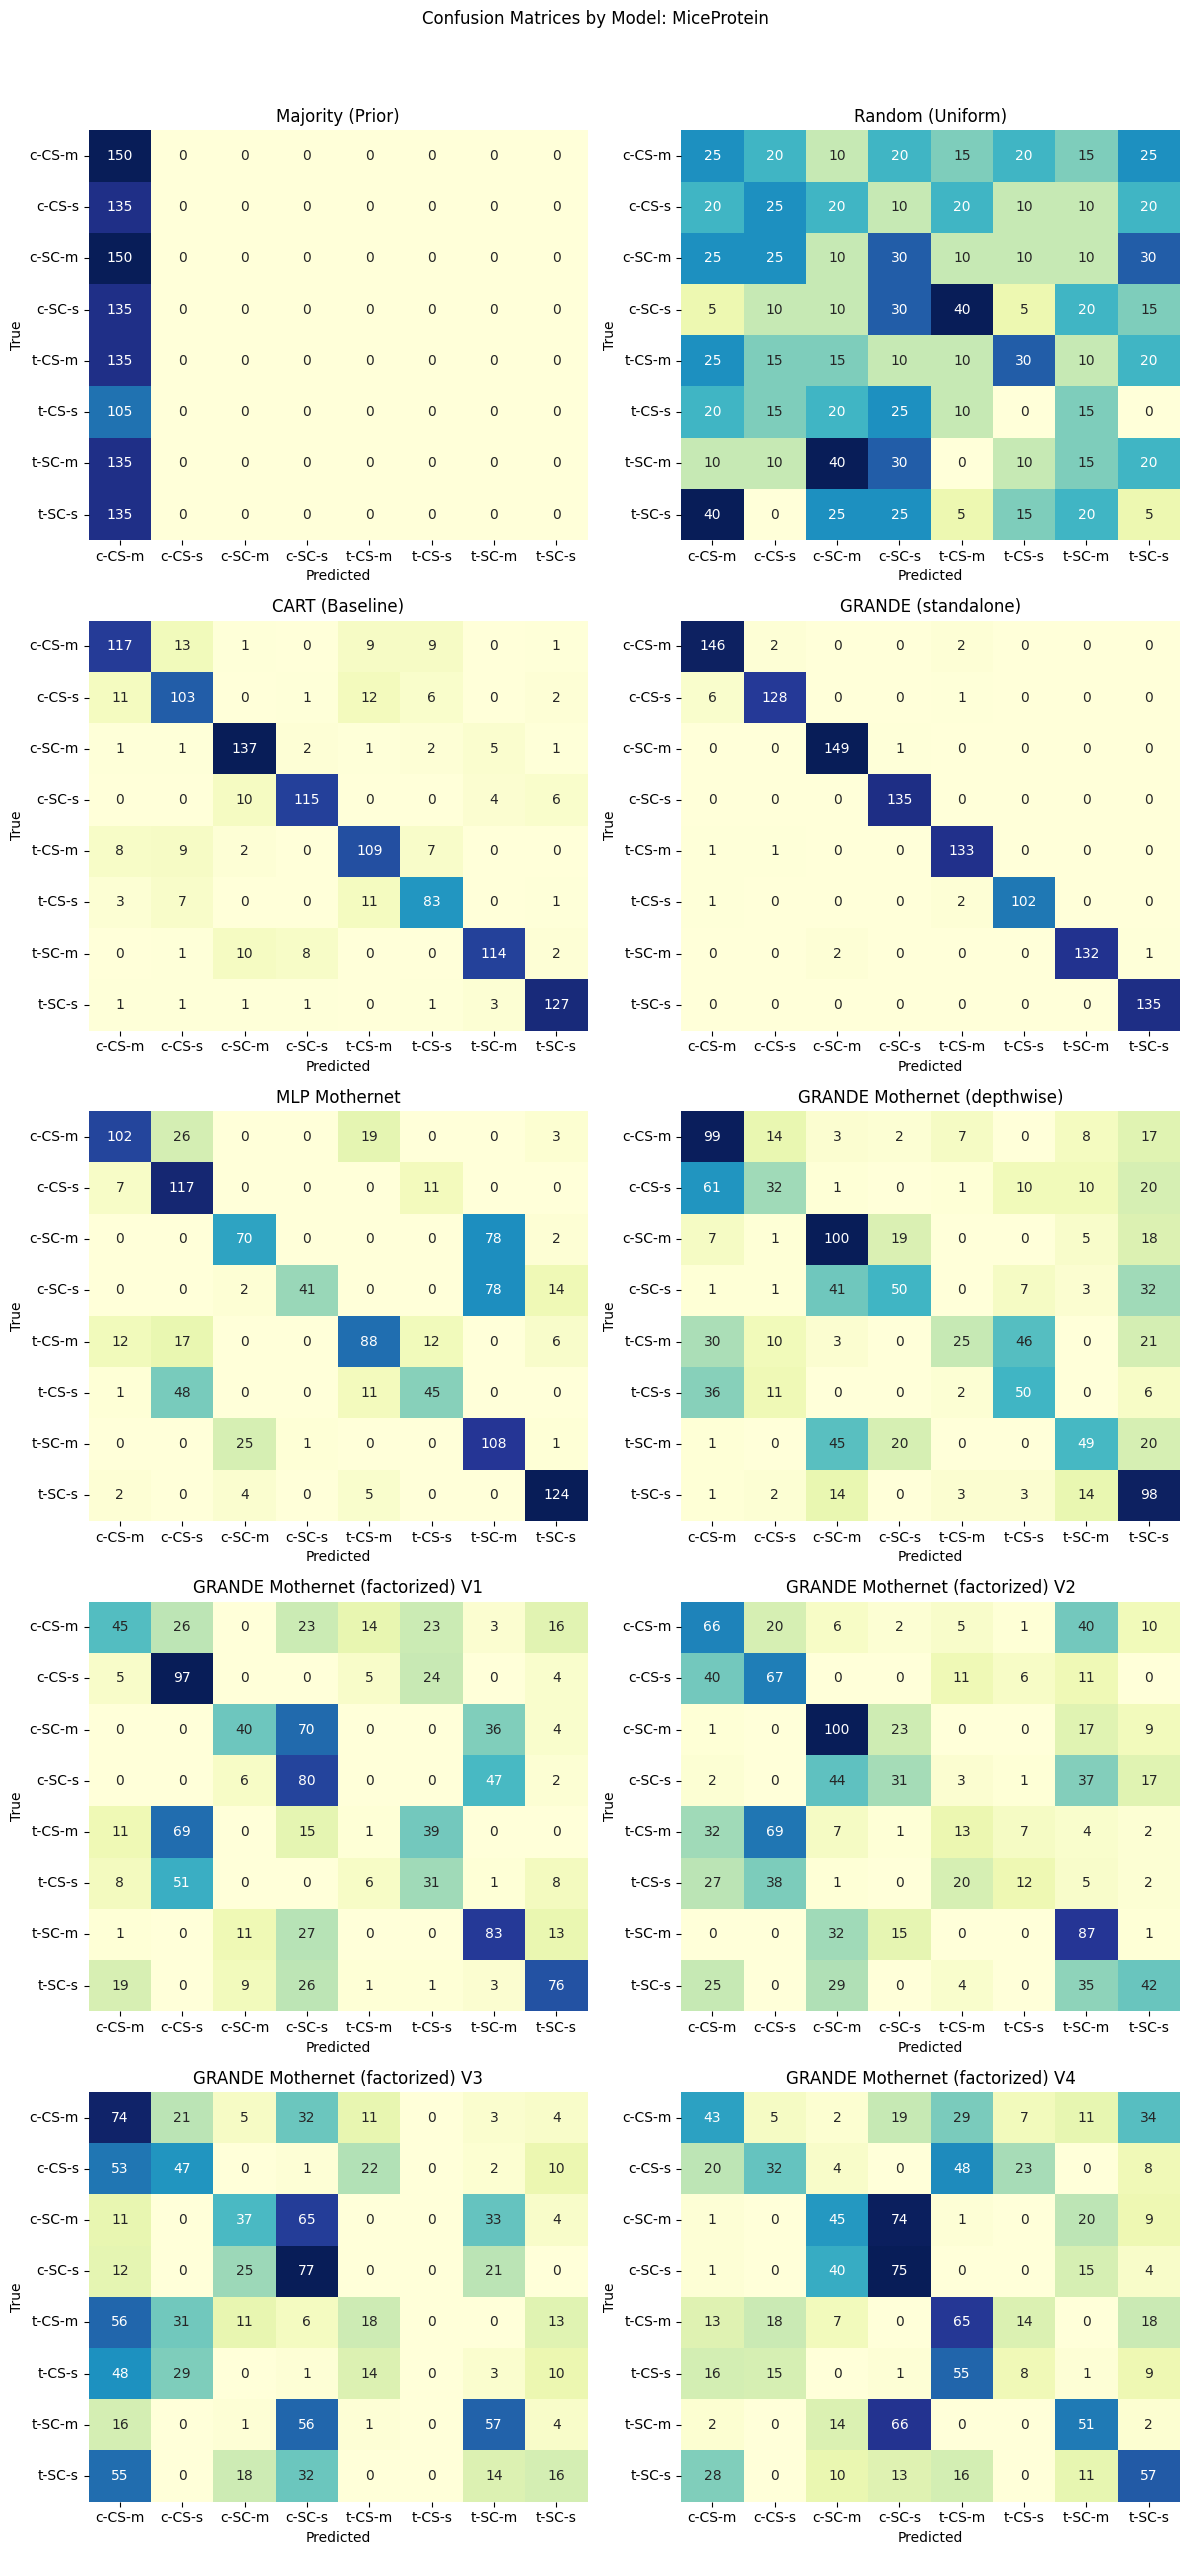

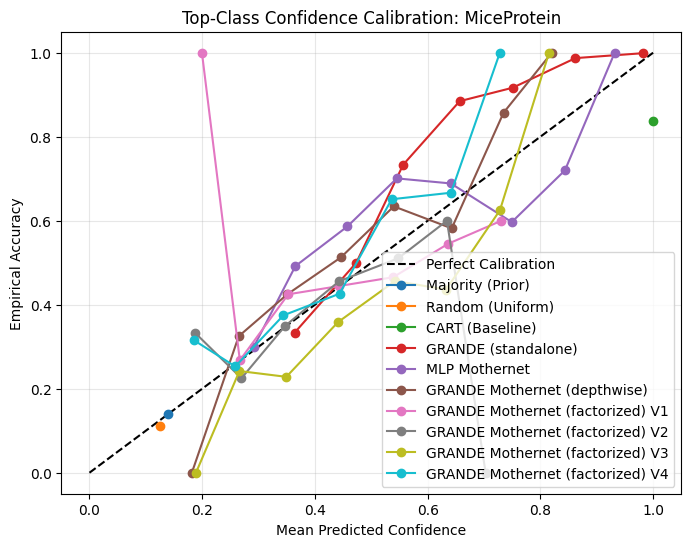


=== Diagnostics: analcatdata_authorship ===


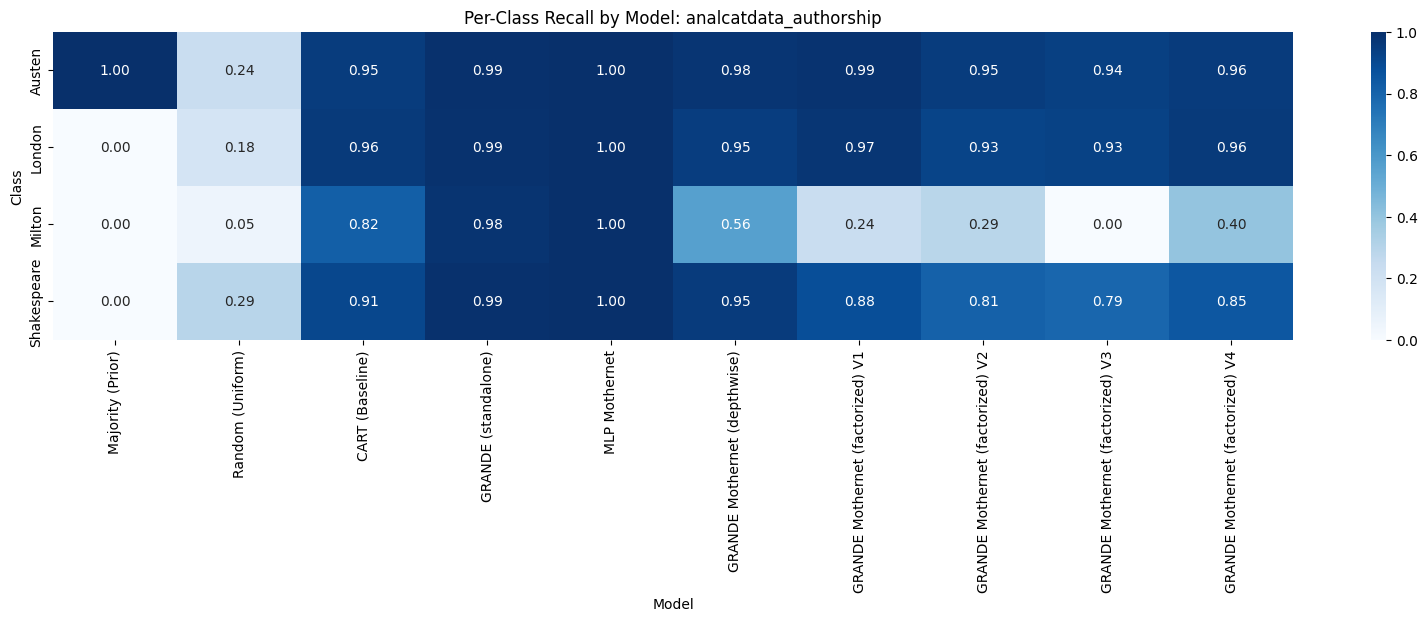

| Class       |   Majority (Prior) |   Random (Uniform) |   CART (Baseline) |   GRANDE (standalone) |   MLP Mothernet |   GRANDE Mothernet (depthwise) |   GRANDE Mothernet (factorized) V1 |   GRANDE Mothernet (factorized) V2 |   GRANDE Mothernet (factorized) V3 |   GRANDE Mothernet (factorized) V4 |
|:------------|-------------------:|-------------------:|------------------:|----------------------:|----------------:|-------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|
| Austen      |                  1 |              0.237 |             0.953 |                 0.994 |           1     |                          0.978 |                              0.987 |                              0.95  |                              0.94  |                              0.956 |
| London      |                  0 |              0.179 |             0.959 |                 0.9

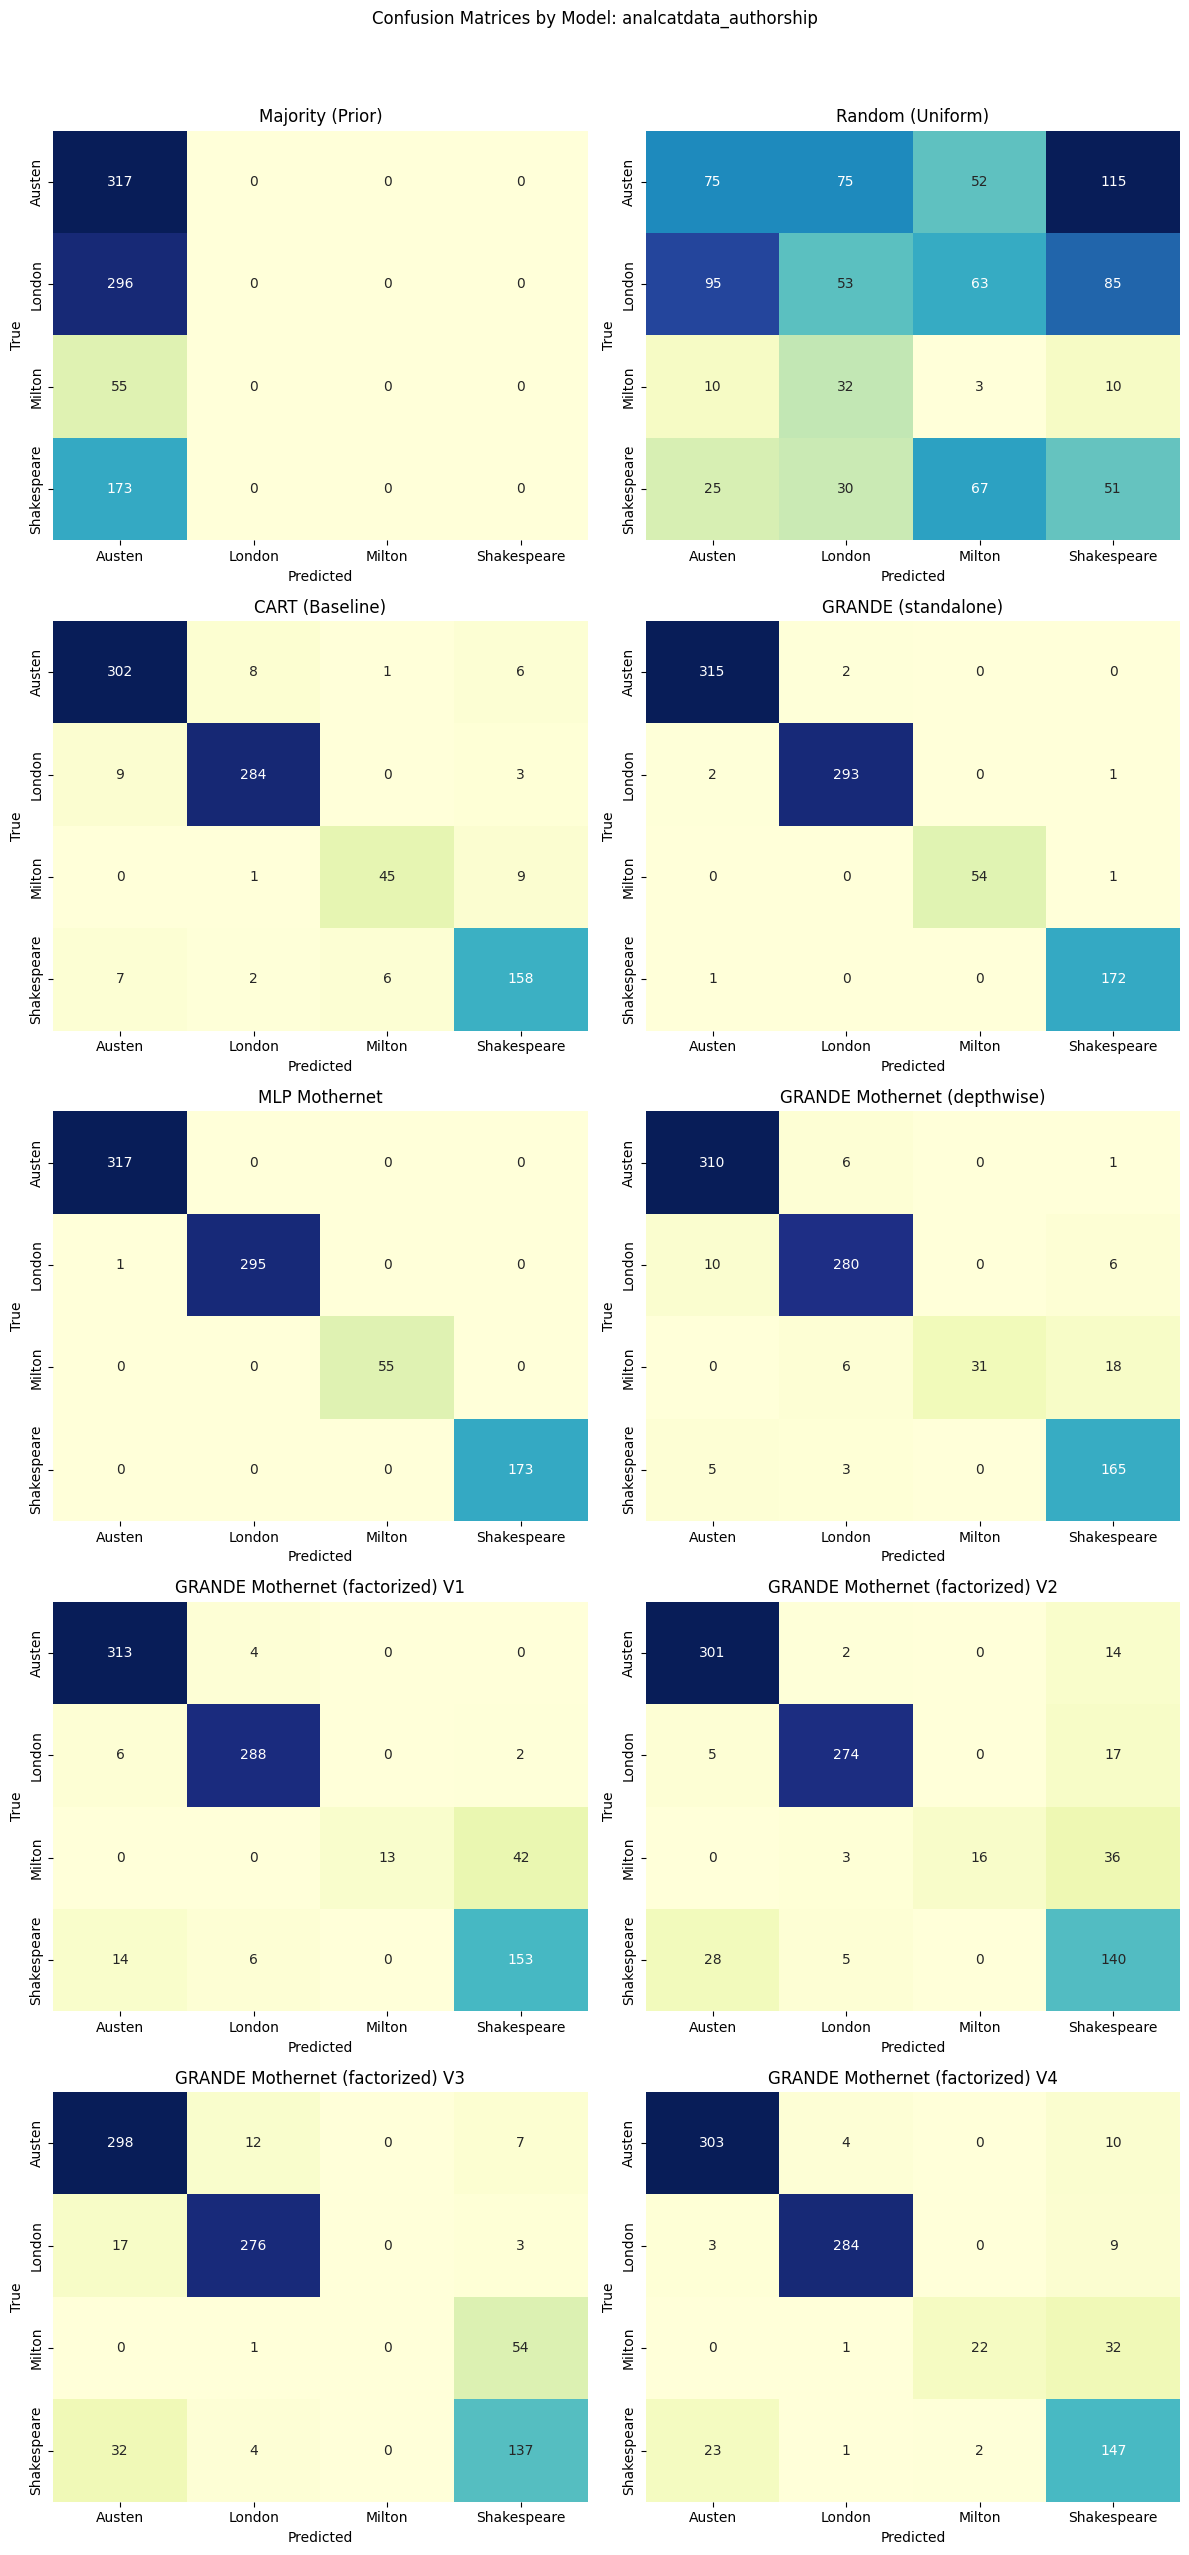

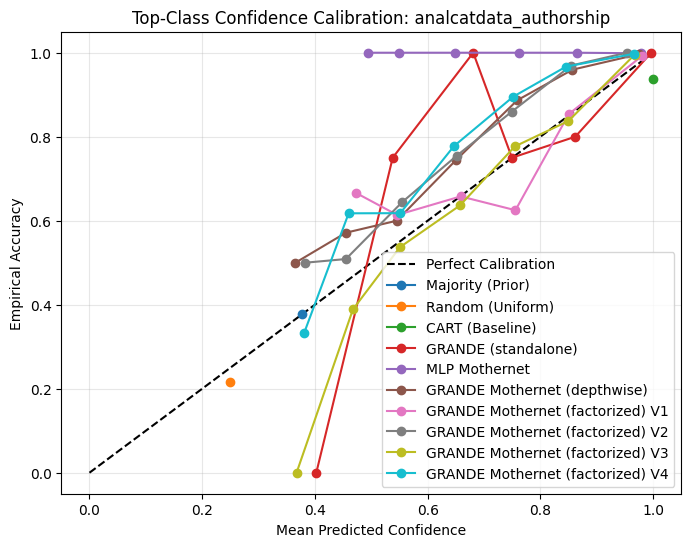


=== Diagnostics: analcatdata_dmft ===


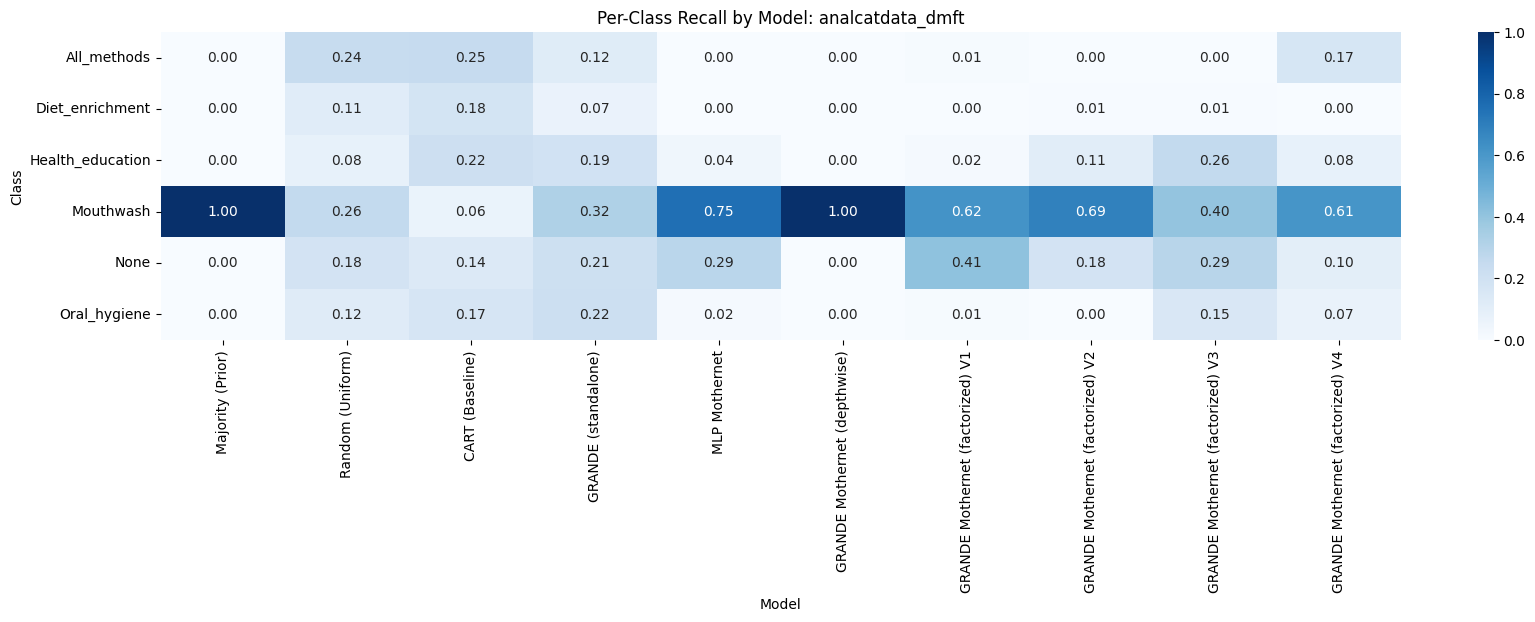

| Class            |   Majority (Prior) |   Random (Uniform) |   CART (Baseline) |   GRANDE (standalone) |   MLP Mothernet |   GRANDE Mothernet (depthwise) |   GRANDE Mothernet (factorized) V1 |   GRANDE Mothernet (factorized) V2 |   GRANDE Mothernet (factorized) V3 |   GRANDE Mothernet (factorized) V4 |
|:-----------------|-------------------:|-------------------:|------------------:|----------------------:|----------------:|-------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|-----------------------------------:|
| All_methods      |                  0 |              0.244 |             0.252 |                 0.118 |           0     |                              0 |                              0.008 |                              0     |                              0     |                              0.165 |
| Diet_enrichment  |                  0 |              0.114 |             0.182 |

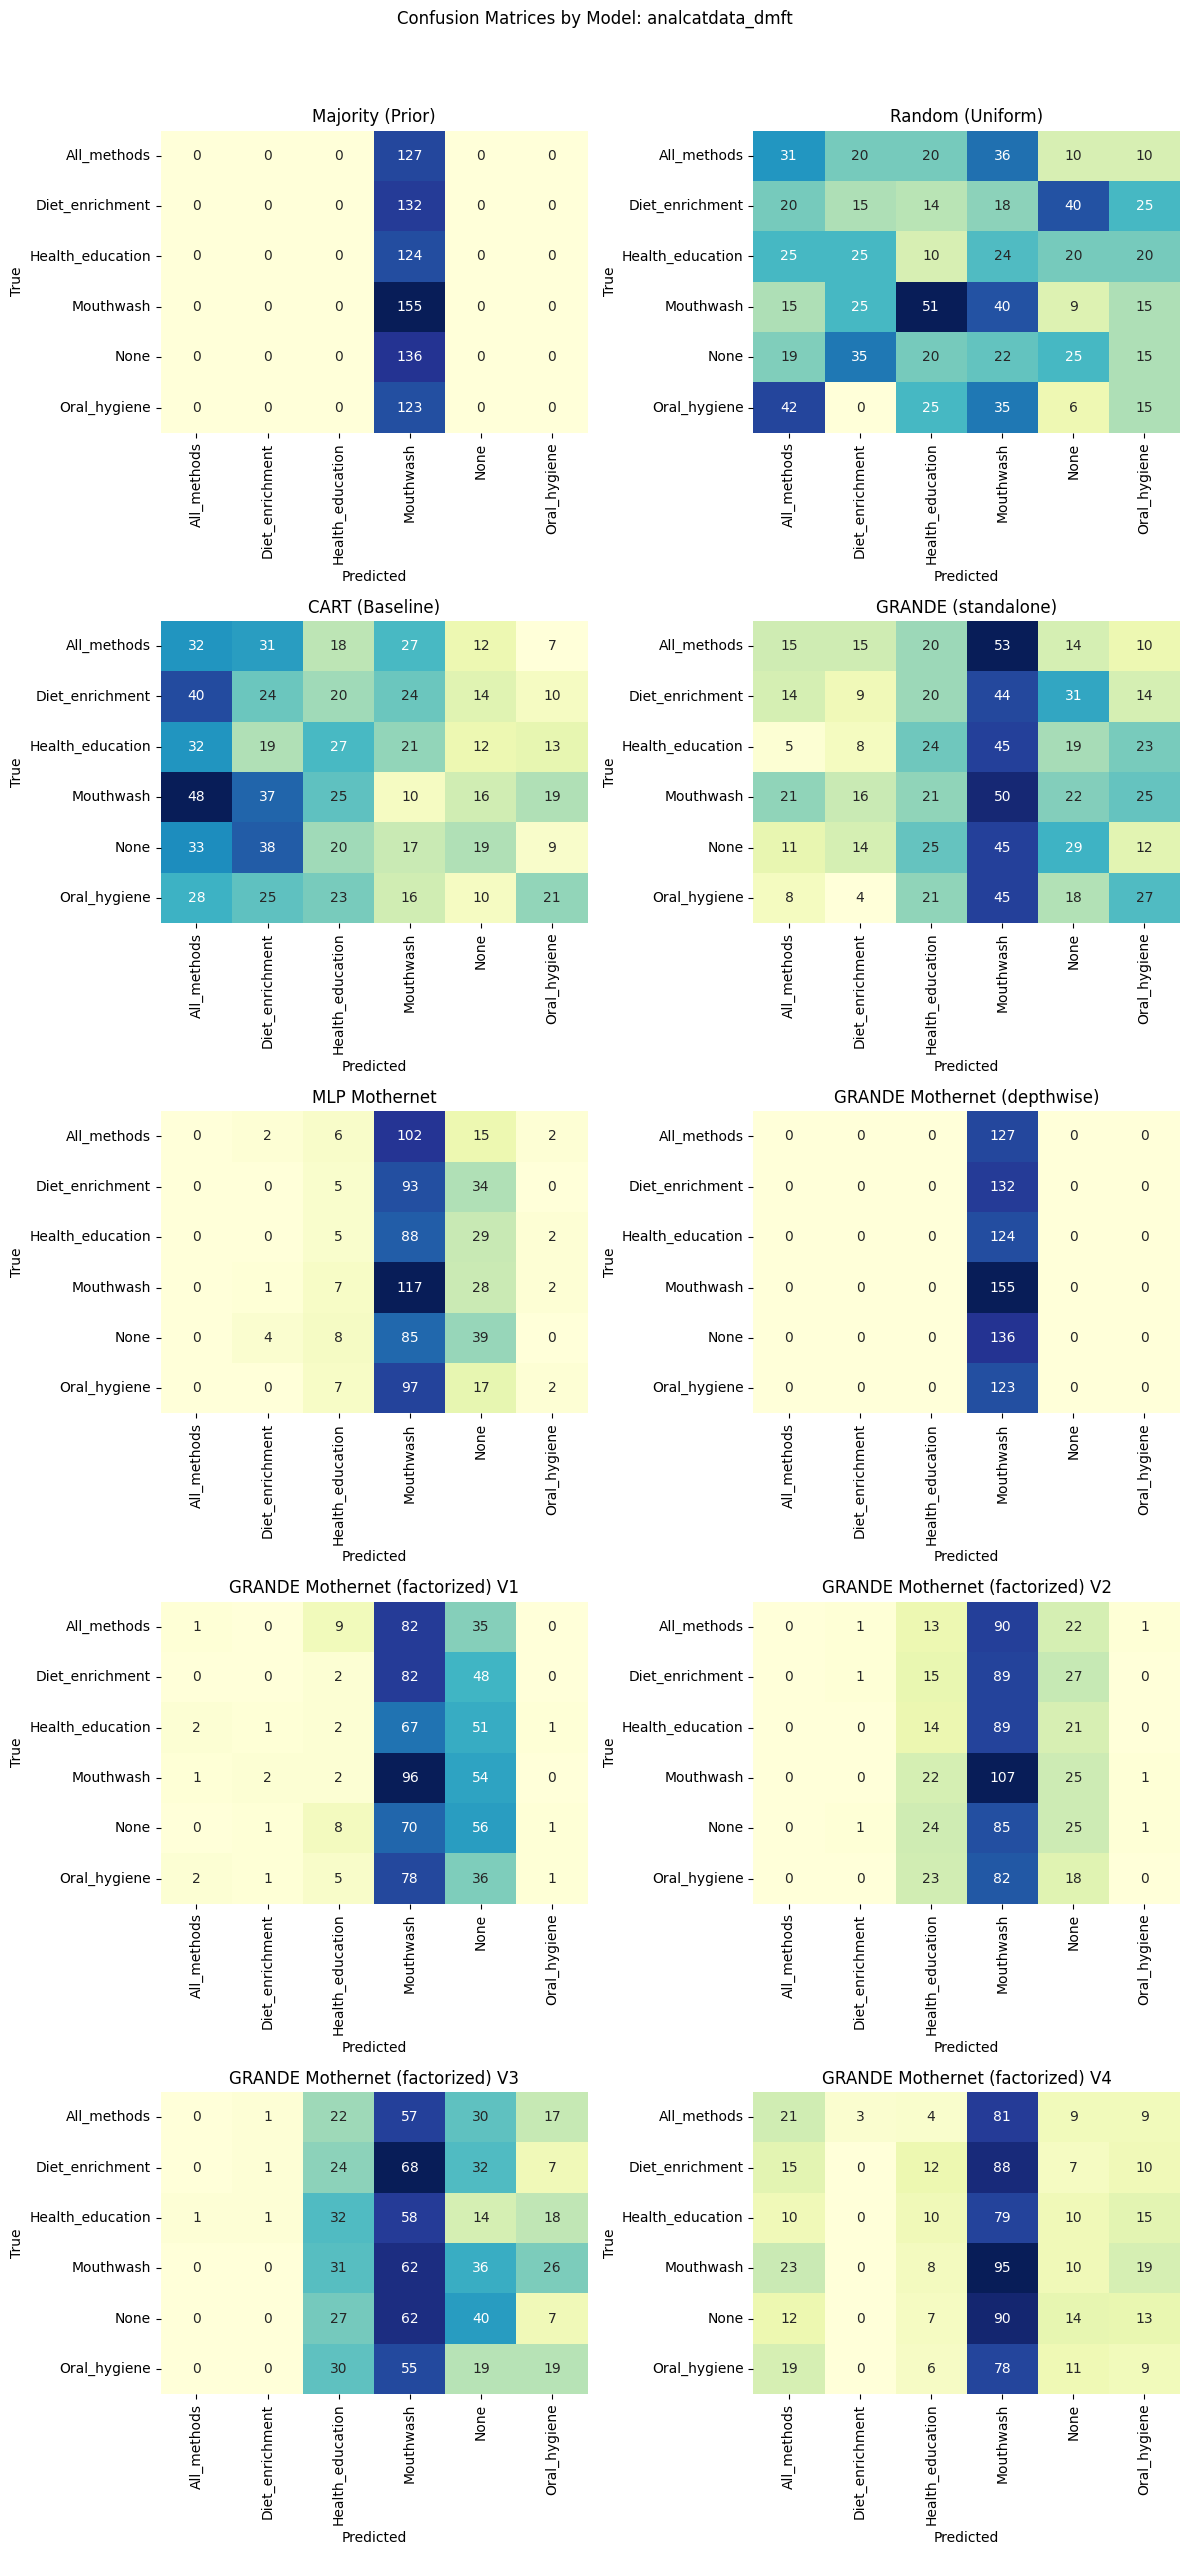

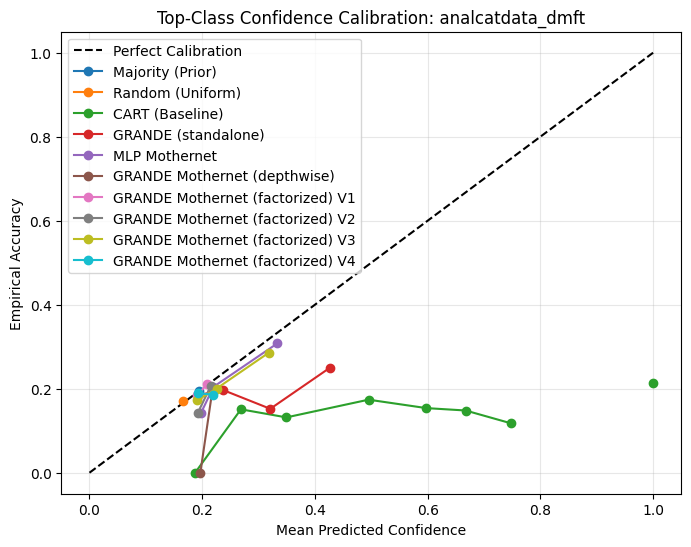

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


def compute_confidence_calibration(predictions_df, dataset_name=None, n_bins=10):
    subset = predictions_df.copy()
    if dataset_name is not None:
        subset = subset[subset['Dataset'] == dataset_name]

    rows = []
    for model_name in model_order:
        model_df = subset[subset['Model'] == model_name].dropna(subset=['confidence']).copy()
        if model_df.empty:
            continue

        model_df['bin'] = pd.cut(
            model_df['confidence'],
            bins=np.linspace(0.0, 1.0, n_bins + 1),
            include_lowest=True,
            duplicates='drop',
        )
        grouped = model_df.groupby('bin', observed=False).agg(
            mean_confidence=('confidence', 'mean'),
            empirical_accuracy=('correct', 'mean'),
            count=('correct', 'size'),
        ).reset_index(drop=True)
        grouped['Model'] = model_name
        rows.append(grouped)

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def plot_confidence_calibration(predictions_df, dataset_name=None, n_bins=10):
    calibration_df = compute_confidence_calibration(predictions_df, dataset_name=dataset_name, n_bins=n_bins)
    if calibration_df.empty:
        return

    title_suffix = "All Datasets" if dataset_name is None else dataset_name
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration')
    for model_name in model_order:
        model_df = calibration_df[calibration_df['Model'] == model_name]
        if model_df.empty:
            continue
        plt.plot(
            model_df['mean_confidence'],
            model_df['empirical_accuracy'],
            marker='o',
            label=model_name,
        )
    plt.title(f"Top-Class Confidence Calibration: {title_suffix}")
    plt.xlabel("Mean Predicted Confidence")
    plt.ylabel("Empirical Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def build_dataset_recall_table(predictions_df, dataset_name):
    subset = predictions_df[predictions_df['Dataset'] == dataset_name].copy()
    if subset.empty:
        return pd.DataFrame()

    labels = sorted(set(subset['y_true']).union(set(subset['y_pred'])))
    rows = []
    for model_name in model_order:
        model_df = subset[subset['Model'] == model_name]
        if model_df.empty:
            continue
        recalls = recall_score(
            model_df['y_true'],
            model_df['y_pred'],
            labels=labels,
            average=None,
            zero_division=0,
        )
        for label, recall_value in zip(labels, recalls):
            rows.append({'Class': label, 'Model': model_name, 'Recall': recall_value})

    recall_df = pd.DataFrame(rows)
    if recall_df.empty:
        return pd.DataFrame()
    return recall_df.pivot(index='Class', columns='Model', values='Recall').reindex(columns=model_order)


def plot_dataset_recall_heatmap(predictions_df, dataset_name):
    recall_table = build_dataset_recall_table(predictions_df, dataset_name)
    if recall_table.empty:
        return

    plt.figure(figsize=(max(10, len(model_order) * 2), max(4, len(recall_table) * 0.5)))
    sns.heatmap(recall_table, annot=True, fmt=".2f", cmap="Blues", vmin=0.0, vmax=1.0)
    plt.title(f"Per-Class Recall by Model: {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Class")
    plt.show()

    print(recall_table.round(3).to_markdown())


def plot_dataset_confusion_matrices(predictions_df, dataset_name):
    subset = predictions_df[predictions_df['Dataset'] == dataset_name].copy()
    if subset.empty:
        return

    labels = sorted(set(subset['y_true']).union(set(subset['y_pred'])))
    n_models = len(model_order)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

    for ax, model_name in zip(axes.flatten(), model_order):
        model_df = subset[subset['Model'] == model_name]
        if model_df.empty:
            ax.axis('off')
            continue

        cm = confusion_matrix(model_df['y_true'], model_df['y_pred'], labels=labels)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='YlGnBu',
            cbar=False,
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_title(model_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    for ax in axes.flatten()[n_models:]:
        ax.axis('off')

    plt.suptitle(f"Confusion Matrices by Model: {dataset_name}", y=1.02)
    plt.tight_layout()
    plt.show()


def select_diagnostic_datasets(results_df, limit):
    pivot = results_df.pivot_table(index='Dataset', columns='Model', values='f1', aggfunc='mean')
    if 'GRANDE Mothernet' in pivot.columns and 'CART (Baseline)' in pivot.columns:
        return (
            pivot.assign(grande_f1_gap=pivot['GRANDE Mothernet'] - pivot['CART (Baseline)'])
            .sort_values('grande_f1_gap')
            .head(limit)
            .index
            .tolist()
        )
    return sorted(results_df['Dataset'].unique())[:limit]


if not df_results.empty:
    melted = df_results.melt(
        id_vars=['Model'],
        value_vars=['accuracy', 'f1', 'roc_auc'],
        var_name='Metric',
        value_name='Score',
    )
    melted['Model'] = pd.Categorical(melted['Model'], categories=model_order, ordered=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric_name in zip(axes, ['accuracy', 'f1', 'roc_auc']):
        metric_df = melted[melted['Metric'] == metric_name]
        sns.boxplot(
            data=metric_df,
            x='Model',
            y='Score',
            hue='Model',
            order=model_order,
            palette='Set2',
            legend=False,
            ax=ax,
        )
        ax.set_title(metric_name.upper())
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle(f"Performance Distribution across OpenML-CC18 Subset (<{MAX_SAMPLES} samples)", y=1.05)
    plt.tight_layout()
    plt.show()

    pivot = df_results.pivot_table(index='Dataset', columns='Model', values='roc_auc')
    pivot = pivot.reindex(columns=model_order)
    print("\nMean ROC AUC per Dataset:")
    print(pivot.round(3).to_markdown())

    plt.figure(figsize=(12, max(6, len(pivot) * 0.45)))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title("Mean ROC AUC per Dataset and Model")
    plt.show()

    plot_confidence_calibration(df_predictions, dataset_name=None, n_bins=10)

    diagnostic_datasets = select_diagnostic_datasets(df_results, DIAGNOSTIC_DATASET_LIMIT)
    print("\nDiagnostic datasets (worst GRANDE vs CART macro-F1 gaps):")
    print(diagnostic_datasets)

    for dataset_name in diagnostic_datasets:
        print(f"\n=== Diagnostics: {dataset_name} ===")
        plot_dataset_recall_heatmap(df_predictions, dataset_name)
        plot_dataset_confusion_matrices(df_predictions, dataset_name)
        plot_confidence_calibration(df_predictions, dataset_name=dataset_name, n_bins=10)
